In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("smartcart_customers.csv")

In [4]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [5]:
df.shape

(2240, 22)

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## DATA PREPROCESSING

In [7]:
# missing values

df["Income"] = df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [9]:
# age

df["Age"] = 2026 - df["Year_Birth"]

In [10]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,88,3,8,10,4,7,0,1,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,1,6,2,1,1,2,5,0,0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,21,42,1,8,2,10,4,0,0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,3,5,2,2,0,4,6,0,0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,27,15,5,5,3,6,5,0,0,45


In [11]:
# tenure

df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst = True)

df["Customer_Tenure_Days"]= (df["Dt_Customer"].max() - df["Dt_Customer"]).dt.days


In [12]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,88,3,8,10,4,7,0,1,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,6,2,1,1,2,5,0,0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,42,1,8,2,10,4,0,0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,5,2,2,0,4,6,0,0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,15,5,5,3,6,5,0,0,45,161


In [13]:
# spending

df["Total_Spending"] = df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+ df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [14]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days',
       'Total_Spending'],
      dtype='object')

In [15]:
#children
df["Total_children"]= df["Teenhome"] + df["Kidhome"]

In [16]:
#Education
df["Education"].value_counts()

df["Education"]= df["Education"].replace({
    "Basic": "Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "PhD": "Postgraduate","Master":"Postgraduate"
})

In [17]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [18]:
# marital status
df["Living_With"]= df["Marital_Status"].replace({
    "Married": "Partner","Together":"Partner",
    "Single":"Alone",
    "Divorced": "Alone",
    "Widow":"Alone","Alone":"Alone",
    "Absurd":"Alone","YOLO":"Alone"
})


# Drop Unnecessary Columns

In [19]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spending',
       'Total_children', 'Living_With'],
      dtype='object')

In [20]:
cols = ["ID","Year_Birth","Kidhome","Teenhome","Marital_Status","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop = cols + spending_cols 
df_cleaned = df.drop(columns = cols_to_drop)

In [21]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_Tenure_Days', 'Total_Spending', 'Total_children',
       'Living_With'],
      dtype='object')

In [22]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# outliers

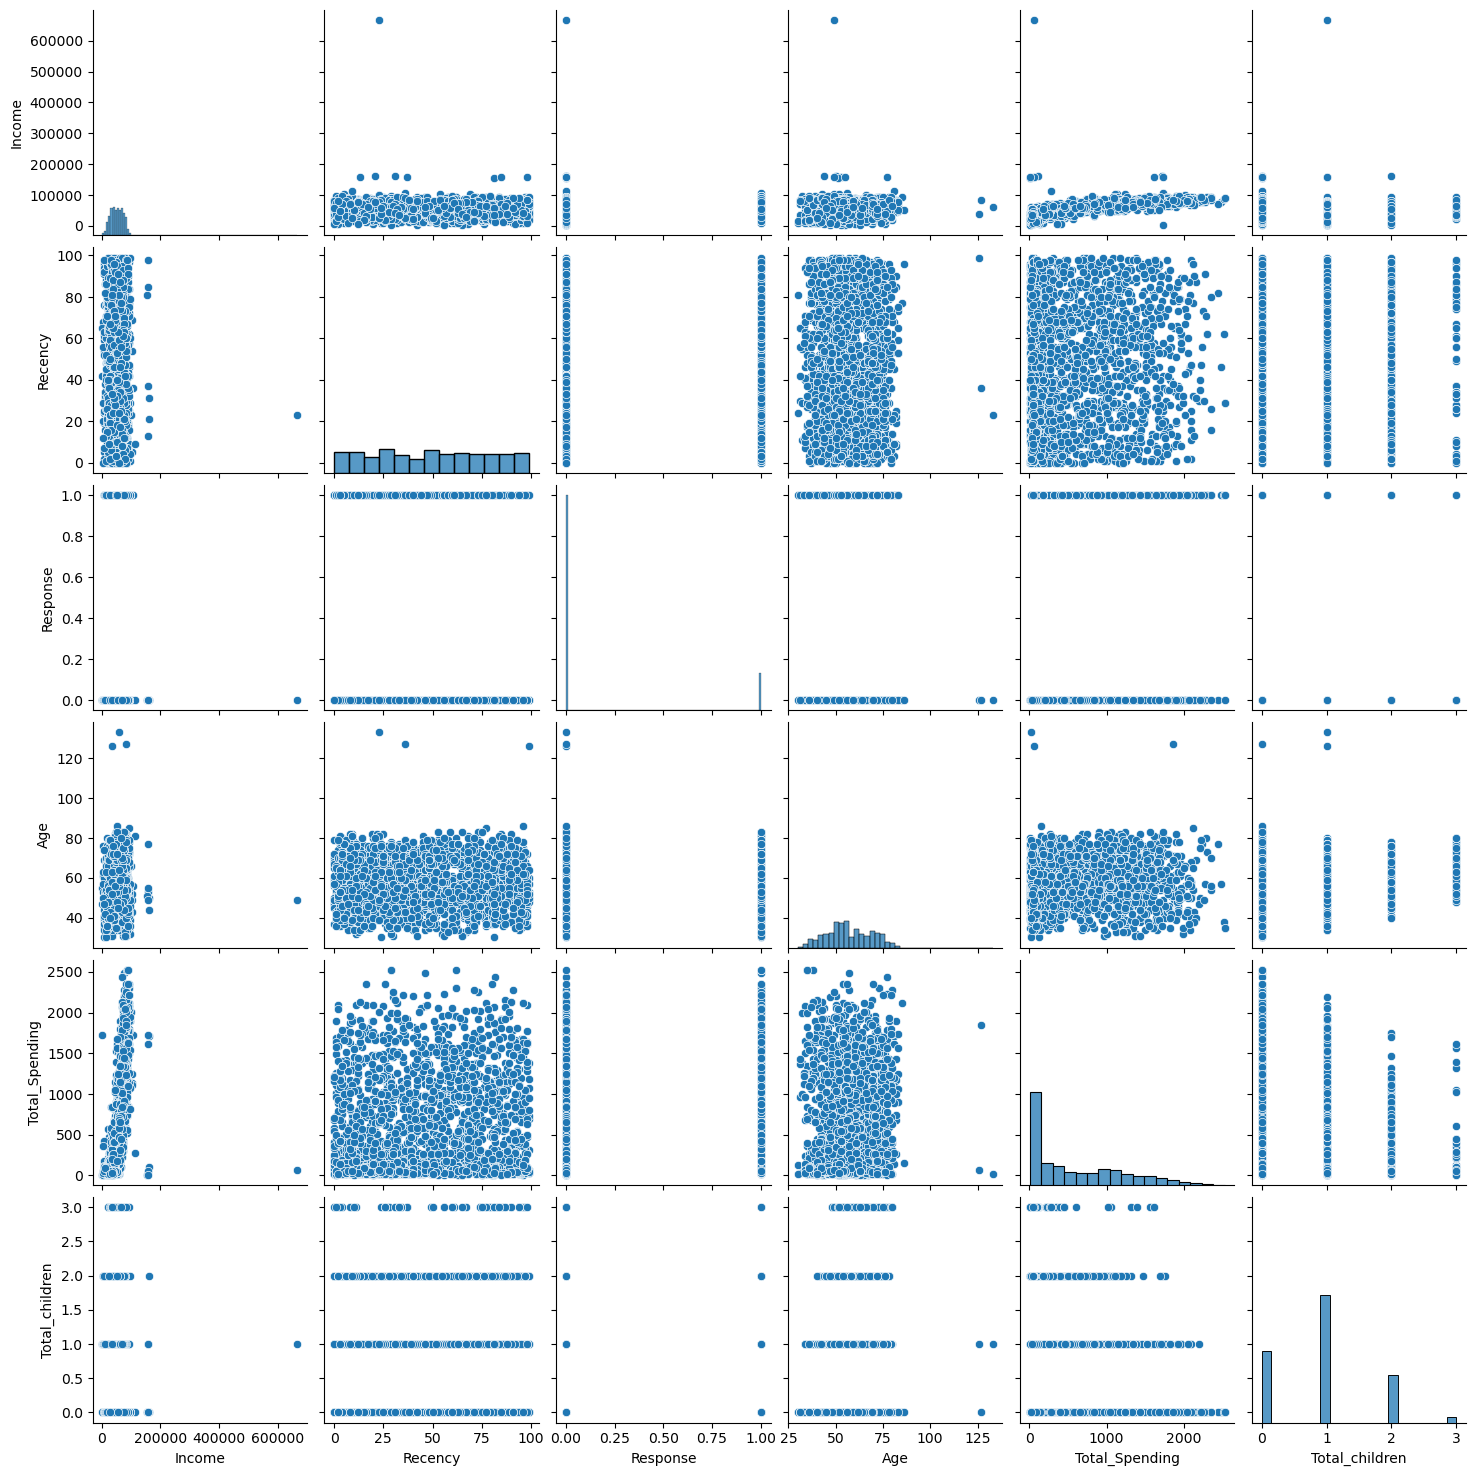

In [23]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_children"]

#pairplot

g= sns.pairplot(df_cleaned[cols])
g.savefig("pairplot.png")

In [24]:
# revenue outlier

print("data size with outliers",len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000)]

print("data size without outliers",len(df_cleaned))

data size with outliers 2240
data size without outliers 2236


#Heatmap

In [25]:
corr = df_cleaned.corr(numeric_only = True)

In [26]:
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

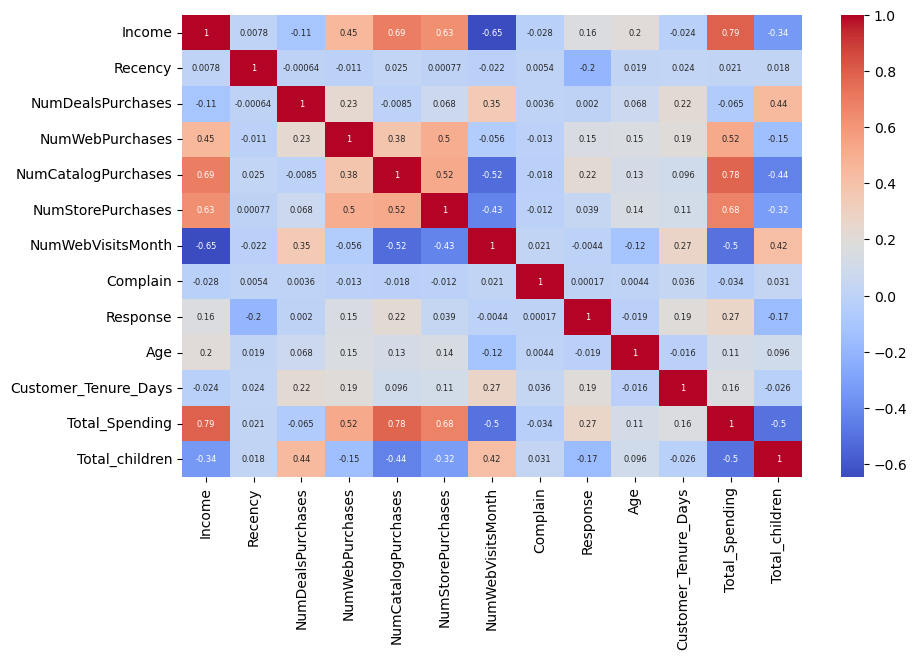

In [27]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot = True,
    annot_kws ={"size":6} , 
    cmap = "coolwarm"
)


# Encoding

In [28]:
from sklearn.preprocessing import OneHotEncoder

In [29]:
ohe = OneHotEncoder()
cat_cols = ["Education","Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [30]:
enc_df = pd.DataFrame(enc_cols.toarray() , columns = ohe.get_feature_names_out(cat_cols),index = df_cleaned.index)

In [31]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [32]:
df_encoded = pd.concat([df_cleaned.drop(columns =cat_cols ),enc_df],axis=1)

In [33]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


#scaling

In [34]:
X = df_encoded

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## visualize

In [36]:
X_scaled.shape

(2236, 18)

In [37]:
# 2D

from sklearn.decomposition import PCA 

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)


<Axes: >

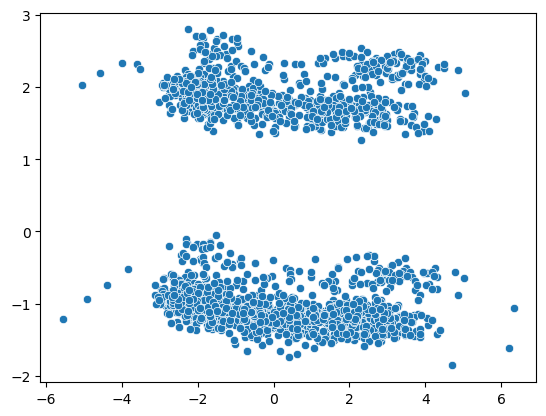

In [38]:
sns.scatterplot(x = X_pca[:,0] , y=X_pca[:,1])

In [39]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

Text(0.5, 0.92, '3D Projection')

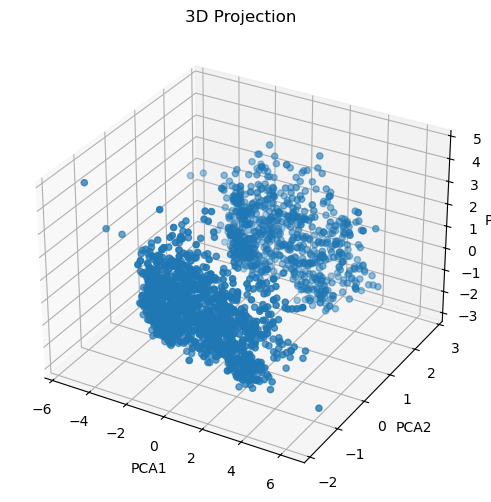

In [40]:
#3d
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize = (8,6))

ax=fig.add_subplot(111, projection = "3d") 

ax.scatter( X_pca[:,0] , X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3D Projection")

In [41]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

## analyze k value

In [42]:
#elbow method

from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)
    

In [43]:
knee = KneeLocator(range(1,11) , wcss , curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [44]:
print("best k : ",optimal_k)

best k :  4


Text(0, 0.5, 'wcss')

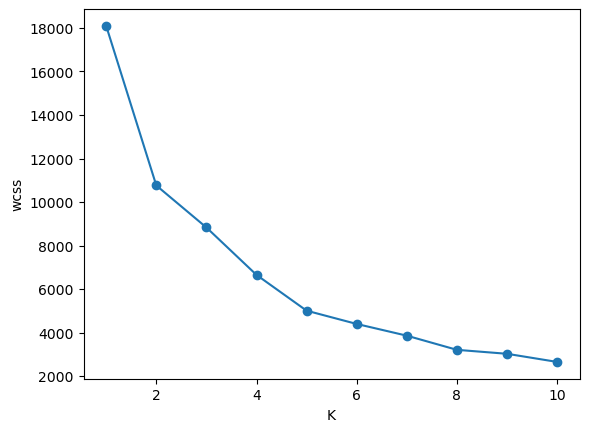

In [45]:
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("wcss")

## silhouttee score

Text(0, 0.5, 'scores')

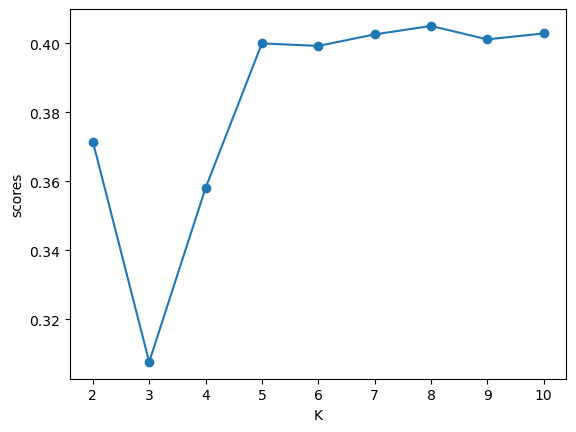

In [46]:
from sklearn.metrics import silhouette_score

scores = [] 

for k in range(2,11):
    kmeans = KMeans(n_clusters = k , random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca , labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("scores")

Text(0, 0.5, 'SS')

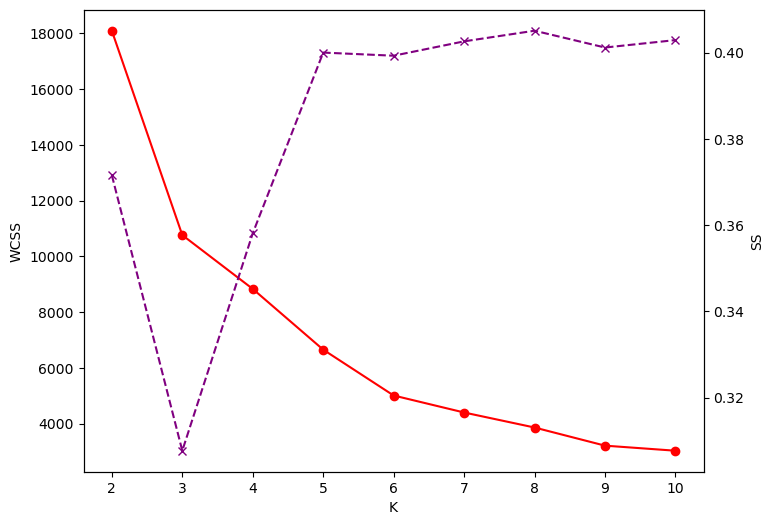

In [47]:
# combine range

k_range = range(2,11)

fig , ax1= plt.subplots(figsize=(8,6))
ax1.plot(k_range , wcss[:len(k_range)],marker = 'o',color='red')
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range , scores[:len(k_range)],marker = 'x',color='purple', linestyle ="--")
ax2.set_ylabel("SS")

## clustering

Text(0.5, 0.92, '3D Projection - KMeans')

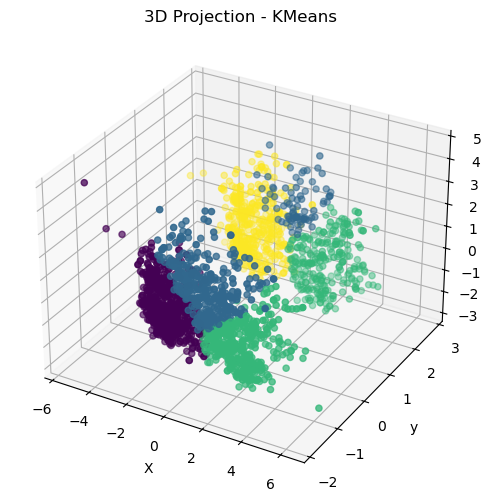

In [48]:
kmeans = KMeans(n_clusters = 4 , random_state = 42)
labels_kmeans = kmeans.fit_predict(X_pca)


fig = plt.figure(figsize = (8,6))

ax=fig.add_subplot(111, projection = "3d") 

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_zlabel("Z")
ax.set_title("3D Projection - KMeans")

Text(0.5, 0.92, '3D Projection')

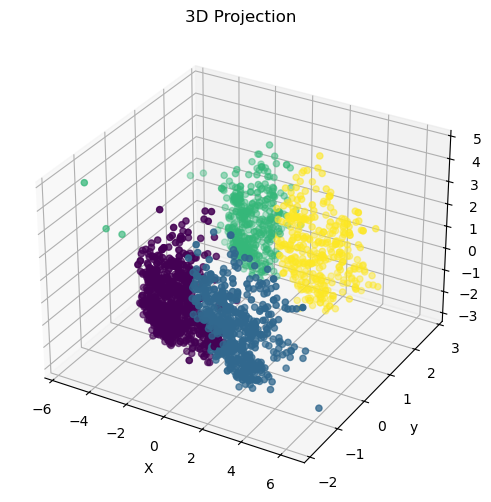

In [49]:
from sklearn.cluster import AgglomerativeClustering

ac = AgglomerativeClustering(n_clusters = 4 , linkage="ward")
labels_ac = ac.fit_predict(X_pca)

#plot
fig = plt.figure(figsize = (8,6))

ax=fig.add_subplot(111, projection = "3d") 

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_ac)
ax.set_xlabel("X")
ax.set_ylabel("y")
ax.set_zlabel("Z")
ax.set_title("3D Projection - Agglomerative Clustering")

## Characterization of Clusters

In [50]:

X["cluster"] = labels_ac 

In [51]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

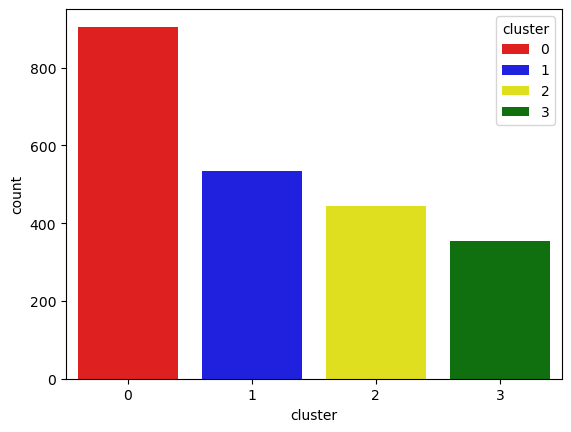

In [52]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette = pal , hue =X["cluster"] )

<Axes: xlabel='Total_Spending', ylabel='Income'>

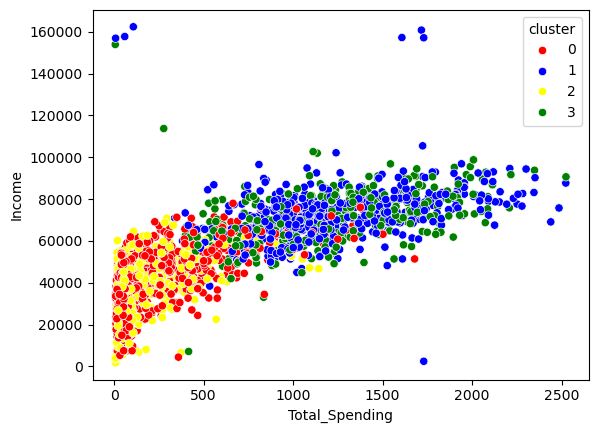

In [53]:
 # Income and Spending values

sns.scatterplot(x= X["Total_Spending"], y=X["Income"] , hue = X["cluster"] , palette = pal)

In [54]:
# cluster summary 

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
cluster         